# 2D Ising Model: Monte Carlo Simulation

Metropolis simulation of a 2D Ising model on an `N x N` lattice with periodic
boundary conditions and an optional external field `H`. Energies and
temperatures are in reduced units (`J = 1`, `k_B = 1`).

The notebook runs top to bottom: model definition, temperature sweeps at
`H = 0` and `H = 0.2`, hysteresis loops, and the entropy obtained by
integrating the heat capacity.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numba import njit

N = 50  # Lattice side length
J = 1  # Exchange coupling
T_C = 2.269  # Theoretical critical temperature (zero field, infinite lattice)

## Model

In [2]:
@njit
def periodic(grid):
    """Refresh the ghost rows and columns so the lattice wraps around."""
    grid[0] = grid[N]
    grid[:, 0] = grid[:, N]
    grid[N + 1] = grid[1]
    grid[:, N + 1] = grid[:, 1]


@njit
def neighbours(i, j, grid):
    """Return the four nearest-neighbour spins of site (i, j)."""
    top = grid[i - 1, j]
    bottom = grid[i + 1, j]
    left = grid[i, j - 1]
    right = grid[i, j + 1]
    return np.array([top, bottom, left, right])


@njit
def energy_magnetization(grid, H):
    """Return the total energy and the magnetization per spin of the lattice."""
    bonds = 0.0
    for i in range(1, N + 1):
        for j in range(1, N + 1):
            # Right and bottom neighbours only, so each bond is counted once
            bonds += grid[i, j] * (grid[i, j + 1] + grid[i + 1, j])
    total_spin = np.sum(grid[1 : N + 1, 1 : N + 1])
    E = -J * bonds - H * total_spin
    M = total_spin / N**2
    return E, M


@njit
def flip(E, M, kbt, grid, H):
    """Attempt one Metropolis spin flip and return the updated (E, M)."""
    i = np.random.randint(1, N + 1)
    j = np.random.randint(1, N + 1)

    spin = grid[i, j]
    nesum = np.sum(neighbours(i, j, grid))
    delta_e = 2 * J * spin * nesum + 2 * H * spin

    # Accept downhill moves always, uphill moves with Boltzmann probability
    if delta_e <= 0 or np.random.rand() < np.exp(-delta_e / kbt):
        grid[i, j] = -spin
        periodic(grid)
        E = E + delta_e
        M = M + (-2 * spin / N**2)
    return E, M


@njit
def sweep(E, M, kbt, grid, H):
    """Run one Monte Carlo sweep (N * N flip attempts)."""
    for _ in range(N * N):
        E, M = flip(E, M, kbt, grid, H)
    return E, M

## Temperature sweep

For each temperature the lattice is thermalized, then `|M|`, `E` and the heat
capacity `C_v` (per spin) are averaged over the measurement sweeps. Snapshots are kept
at temperatures below, near and above `T_c`.

In [3]:
THERMALIZATION_SWEEPS = 10_000
MEASUREMENT_SWEEPS = 1_000
SNAPSHOT_TEMPS = [1.5, 2.3, 2.8]
TEMPS = np.arange(0.1, 5, 0.1)


def run_temperature_sweep(H):
    """Simulate every temperature in TEMPS at field H and collect observables."""
    avg_mag, avg_energy, cv = [], [], []
    energy_snapshots, spin_snapshots = {}, {}

    for kbt in TEMPS:
        mags, energies = [], []
        grid = np.random.choice([-1, 1], size=(N + 2, N + 2))
        periodic(grid)
        E, M = energy_magnetization(grid, H)

        # Thermalize to reach equilibrium
        for _ in range(THERMALIZATION_SWEEPS):
            E, M = sweep(E, M, kbt, grid, H)

        # Measure physical quantities
        for _ in range(MEASUREMENT_SWEEPS):
            E, M = sweep(E, M, kbt, grid, H)
            mags.append(np.abs(M))
            energies.append(E)

        avg_mag.append(np.mean(mags))
        avg_energy.append(np.mean(energies))
        cv.append(np.var(energies) / N**2 / kbt**2)  # Per spin

        if any(np.isclose(kbt, t, atol=0.01) for t in SNAPSHOT_TEMPS):
            energy_snapshots[round(kbt, 3)] = energies.copy()
            spin_snapshots[round(kbt, 3)] = grid[1 : N + 1, 1 : N + 1].copy()

    return {
        "mag": np.array(avg_mag),
        "energy": np.array(avg_energy),
        "cv": np.array(cv),
        "energy_snapshots": energy_snapshots,
        "spin_snapshots": spin_snapshots,
    }

In [4]:
def plot_results(results, H):
    """Plot spin snapshots, magnetization, energy histograms and heat capacity."""
    suffix = f"(H = {H})"

    # Spin configurations
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (temp, spins) in zip(axs, results["spin_snapshots"].items(), strict=False):
        ax.imshow(spins, cmap="gray", interpolation="nearest")
        ax.set_title(f"kBT = {temp}")
        ax.axis("off")
    fig.suptitle(f"Spin Configurations {suffix}", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Magnetization vs temperature
    plt.figure(figsize=(8, 5))
    plt.plot(TEMPS, results["mag"], marker="o")
    plt.axvline(x=T_C, color="red", linestyle="--", label="Theoretical $T_c$")
    plt.title(f"Magnetization vs Temperature {suffix}")
    plt.xlabel("kBT")
    plt.ylabel("|M|")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Energy histograms
    colors = ["blue", "green", "red"]
    plt.figure(figsize=(8, 5))
    for color, (temp, energies) in zip(
        colors, results["energy_snapshots"].items(), strict=False
    ):
        plt.hist(
            energies,
            bins=40,
            alpha=0.5,
            label=f"kBT = {temp}",
            color=color,
            density=True,
        )
    plt.title(f"Energy Histograms at Selected Temperatures {suffix}")
    plt.xlabel("Energy")
    plt.ylabel("Normalized Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Heat capacity vs temperature
    plt.figure(figsize=(8, 5))
    plt.plot(TEMPS, results["cv"], color="red")
    plt.axvline(x=T_C, color="red", linestyle="--", label="Theoretical $T_c$")
    plt.title(f"Heat Capacity vs Temperature {suffix}")
    plt.xlabel("Temperature (kBT)")
    plt.ylabel("Heat Capacity per Spin (C_v)")
    plt.legend()
    plt.grid(True)
    plt.show()

### Zero field (H = 0)

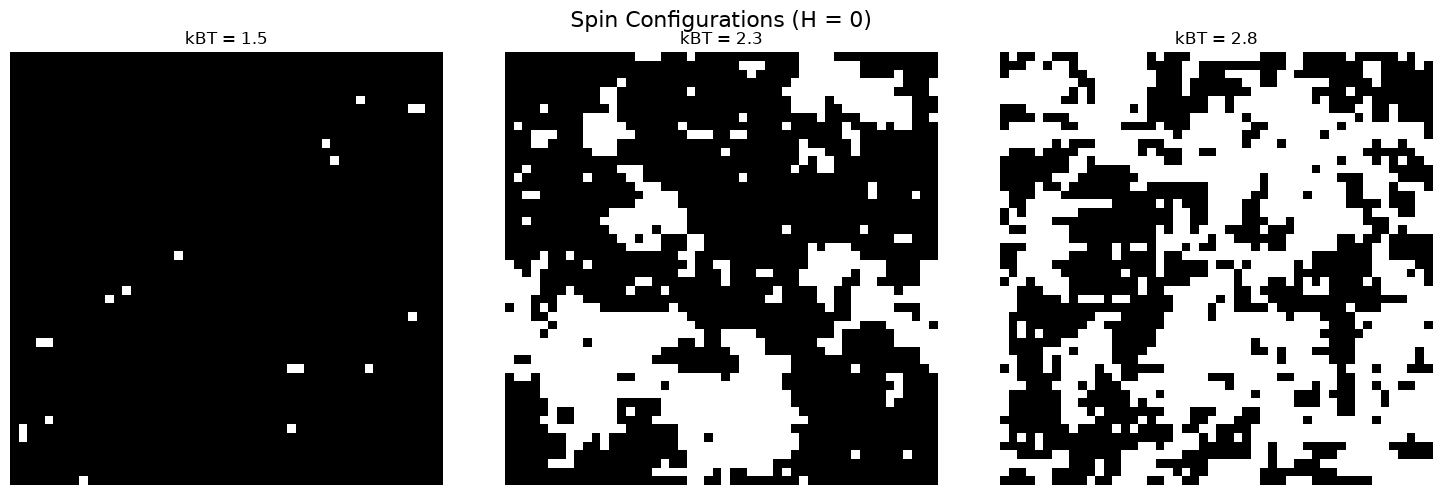

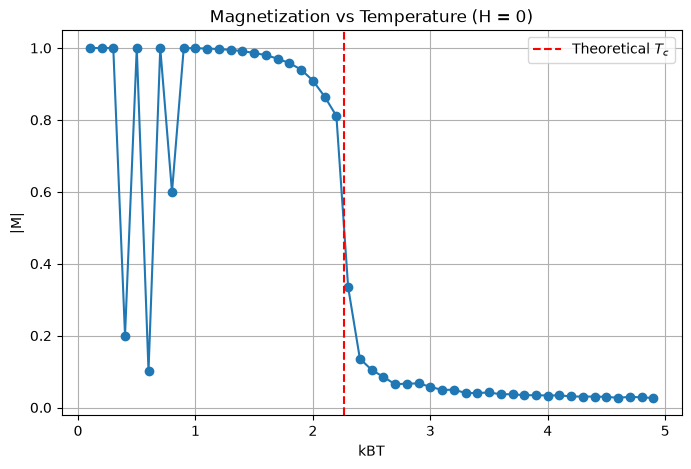

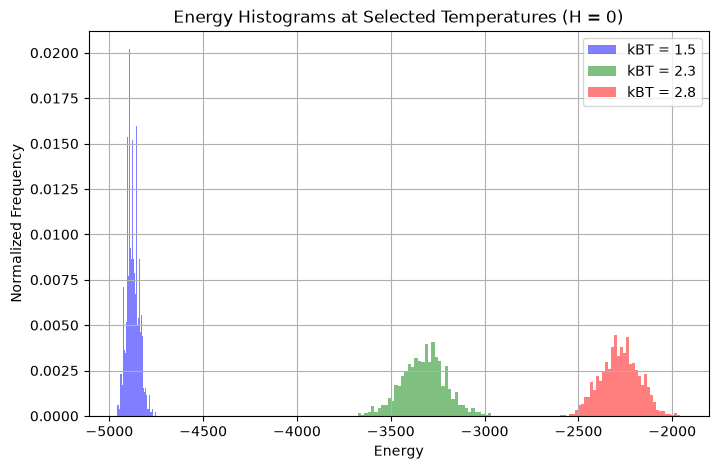

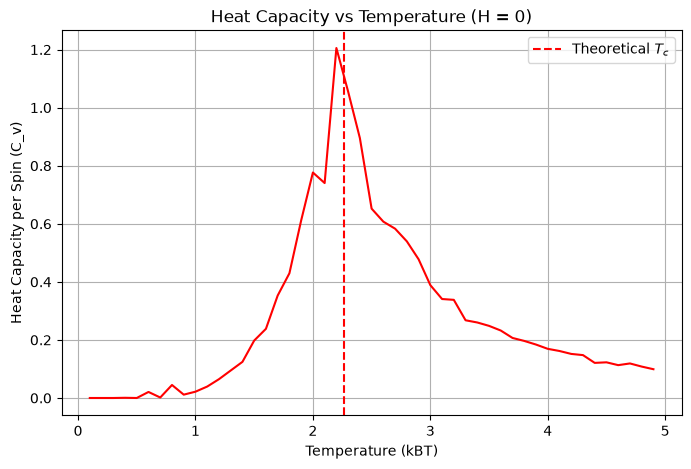

In [5]:
H = 0
results_h0 = run_temperature_sweep(H)
plot_results(results_h0, H)

### Applied field (H = 0.2)

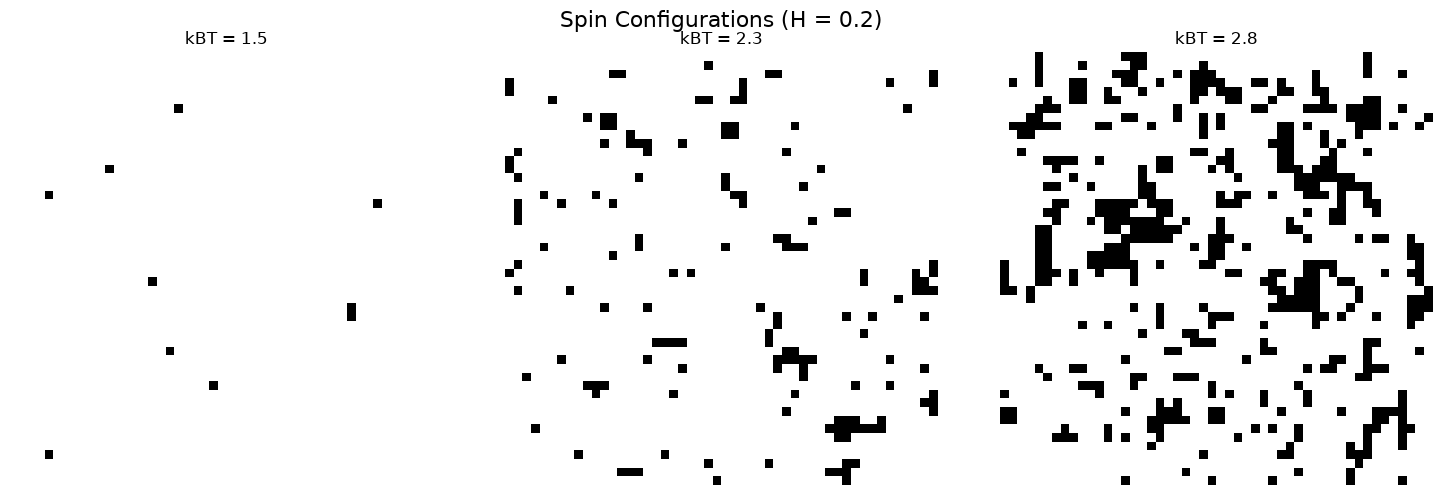

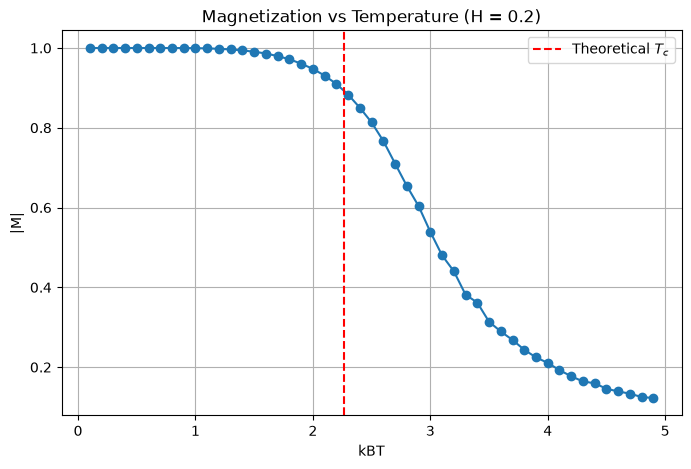

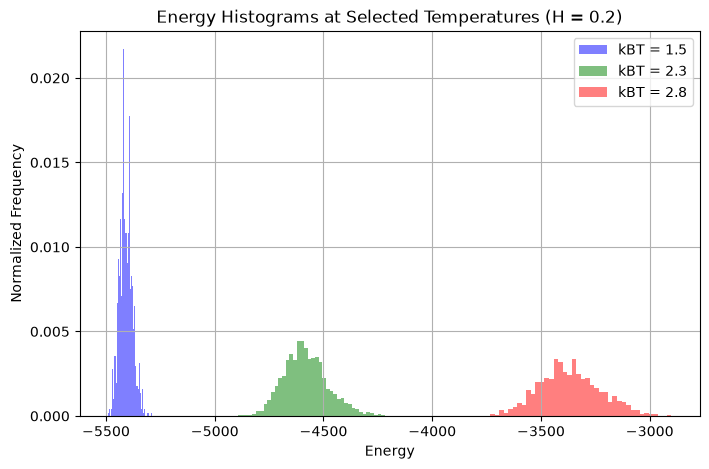

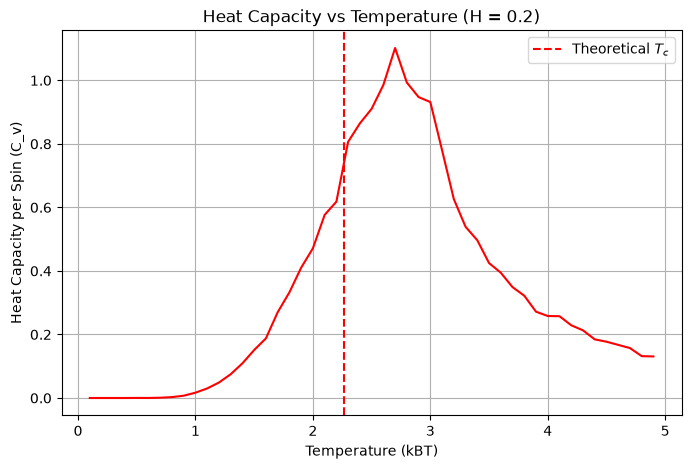

In [6]:
H = 0.2
results_h02 = run_temperature_sweep(H)
plot_results(results_h02, H)

## Hysteresis loops

The field is swept from `-H_max` to `+H_max` and back at fixed temperature,
starting from a fully ordered lattice.

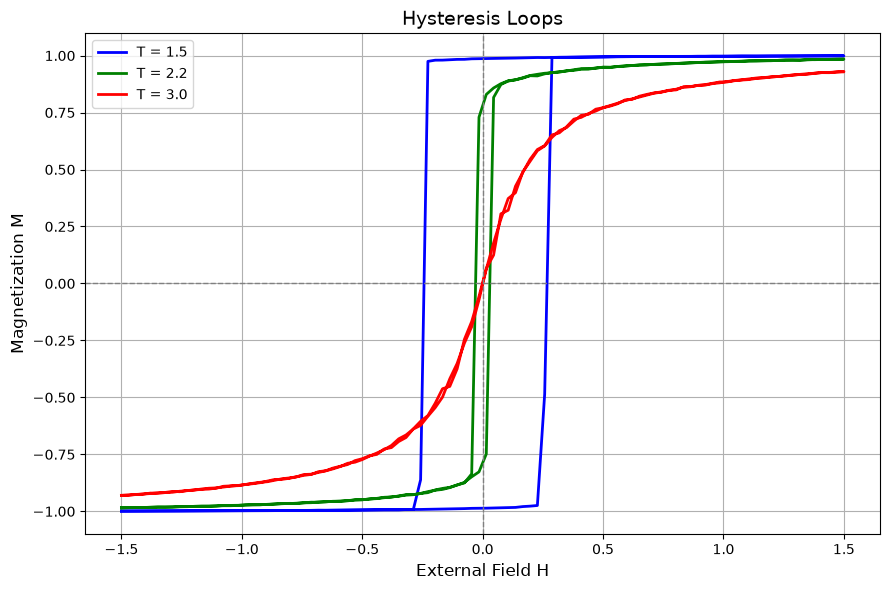

In [7]:
HYSTERESIS_TEMPS = [1.5, 2.2, 3.0]  # Low, near-critical and high temperature
H_MAX = 1.5
FIELD_STEPS = 100
RELAX_SWEEPS = 300
MEASURE_SWEEPS = 300

h_vals = np.concatenate(
    (np.linspace(-H_MAX, H_MAX, FIELD_STEPS), np.linspace(H_MAX, -H_MAX, FIELD_STEPS))
)

plt.figure(figsize=(9, 6))
for color, temp in zip(["blue", "green", "red"], HYSTERESIS_TEMPS, strict=True):
    grid = np.ones((N + 2, N + 2))  # Restart from an ordered lattice for each T
    periodic(grid)
    E, M = energy_magnetization(grid, h_vals[0])
    mags_hyst = []

    for field in h_vals:
        # Relax at the new field
        for _ in range(RELAX_SWEEPS):
            E, M = sweep(E, M, temp, grid, field)

        # Measure the average magnetization
        mag_vals = []
        for _ in range(MEASURE_SWEEPS):
            E, M = sweep(E, M, temp, grid, field)
            mag_vals.append(M)
        mags_hyst.append(np.mean(mag_vals))

    plt.plot(h_vals, mags_hyst, label=f"T = {temp}", lw=2, color=color)

plt.axhline(0, color="gray", linestyle="--", lw=1)
plt.axvline(0, color="gray", linestyle="--", lw=1)
plt.title("Hysteresis Loops", fontsize=14)
plt.xlabel("External Field H", fontsize=12)
plt.ylabel("Magnetization M", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Entropy

The entropy is obtained by integrating `C_v / T` over temperature, using the
zero-field heat capacity per spin. The result is relative to the
lowest simulated temperature.

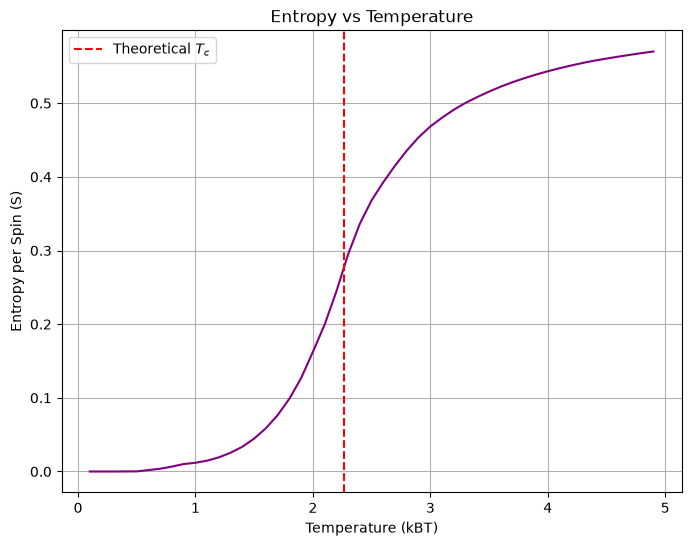

In [8]:
integrand = results_h0["cv"] / TEMPS
entropy = np.array(
    [np.trapezoid(integrand[: i + 1], TEMPS[: i + 1]) for i in range(len(TEMPS))]
)

plt.figure(figsize=(8, 6))
plt.plot(TEMPS, entropy, color="purple")
plt.axvline(x=T_C, color="red", linestyle="--", label="Theoretical $T_c$")
plt.title("Entropy vs Temperature")
plt.xlabel("Temperature (kBT)")
plt.ylabel("Entropy per Spin (S)")
plt.legend()
plt.grid(True)
plt.show()